<a href="https://colab.research.google.com/github/Priyanshiix12/MLE/blob/main/CaseStudy1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount Google Drive to access files persistently
# from google.colab import drive;
# drive.mount('hospital_readmission_synthetic_5000.csv')

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

import matplotlib.pyplot as plt

In [ ]:
# Load the dataset
df = pd.read_csv("/content/hospital_readmission_synthetic_5000.csv/MyDrive/DSA Tracker✨🚀/hospital_readmission_synthetic_5000 .csv")

print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (5000, 14)

First 5 rows:


,age,gender,diagnosis_code,heart_rate,systolic_bp,diastolic_bp,glucose,length_of_stay,previous_visits,previous_admissions,comorbidity_count,medication_count,emergency_visits,readmitted_30_days
0,69,Female,J44,86,149,75,91,1,2,1,2,8,2,0
1,32,Male,E11,73,114,82,63,3,2,2,2,5,1,1
2,89,Female,I10,84,153,77,107,4,1,0,1,7,0,0
3,78,Female,M17,85,146,76,161,3,0,0,1,7,3,0
4,38,Male,M17,65,137,66,65,7,3,0,2,7,1,0


In [ ]:
# Perform initial data exploration
print("Dataset information:")
df.info()
print("\nTarget distribution:")
print(df["readmitted_30_days"].value_counts())

print("\nTarget percentage:")
print(df["readmitted_30_days"].value_counts(normalize=True) * 100)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   age                  5000 non-null   int64 
 1   gender               5000 non-null   object
 2   diagnosis_code       5000 non-null   object
 3   heart_rate           5000 non-null   int64 
 4   systolic_bp          5000 non-null   int64 
 5   diastolic_bp         5000 non-null   int64 
 6   glucose              5000 non-null   int64 
 7   length_of_stay       5000 non-null   int64 
 8   previous_visits      5000 non-null   int64 
 9   previous_admissions  5000 non-null   int64 
 10  comorbidity_count    5000 non-null   int64 
 11  medication_count     5000 non-null   int64 
 12  emergency_visits     5000 non-null   int64 
 13  readmitted_30_days   5000 non-null   int64 
dtypes: int64(12), object(2)
memory usage: 547.0+ KB

Target distribution:
readmitted_30

In [ ]:
# Define categorical and numerical features
categorical_features = [
    "gender",
    "diagnosis_code"
]

numerical_features = [
    "age",
    "heart_rate",
    "systolic_bp",
    "diastolic_bp",
    "glucose",
    "length_of_stay",
    "previous_visits",
    "previous_admissions",
    "comorbidity_count",
    "medication_count",
    "emergency_visits"
]

In [ ]:
# Define preprocessing steps for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [ ]:
# Create the machine learning pipeline
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        ("classifier", LogisticRegression(
            C=1.0,
            max_iter=1000
        ))
    ]
)

In [ ]:
# Split data into training and testing sets
X = df.drop("readmitted_30_days", axis=1)
y = df["readmitted_30_days"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4000
Testing samples: 1000


In [ ]:
# Train the model
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


# New section

In [ ]:
# Predict probabilities for the test set
y_probability = model.predict_proba(X_test)[:, 1]

print("Minimum probability:", y_probability.min())
print("Maximum probability:", y_probability.max())
print("Mean probability:", y_probability.mean())

Minimum probability: 0.03529829333607168
Maximum probability: 0.49376318419772647
Mean probability: 0.15832754608067995


In [ ]:
# Calculate ROC-AUC score
roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.6452016853767053


In [ ]:
# Set classification threshold and make predictions
threshold = 0.30

y_pred = (y_probability >= threshold).astype(int)

print("Classification threshold:", threshold)

Classification threshold: 0.3


In [ ]:
# Print Classification Report
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.96      0.90       838
           1       0.35      0.12      0.18       162

    accuracy                           0.82      1000
   macro avg       0.60      0.54      0.54      1000
weighted avg       0.77      0.82      0.78      1000



In [ ]:
#TP / TN / FP / FN
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[801  37]
 [142  20]]


In [ ]:
# Extract True Negatives, False Positives, False Negatives, True Positives
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 801
False Positives: 37
False Negatives: 142
True Positives : 20


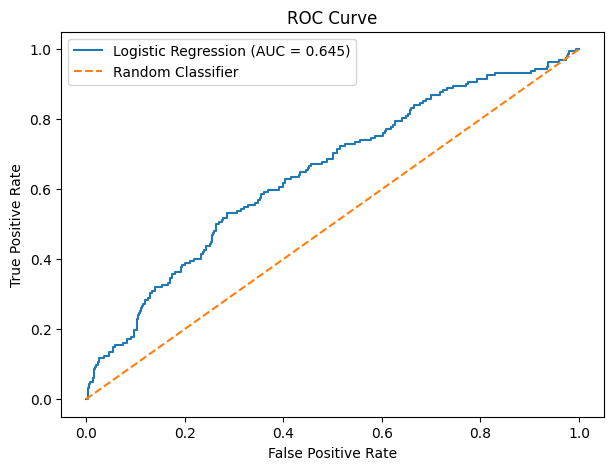

In [ ]:
# Threshold & Clinical Cost Analysis
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
# Analyze performance at different thresholds
thresholds_to_test = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

results = []

for threshold in thresholds_to_test:

    predictions = (
        y_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    results.append({
        "Threshold": threshold,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Recall": recall,
        "Precision": precision
    })

threshold_df = pd.DataFrame(results)

display(threshold_df)

,Threshold,TP,FP,FN,TN,Recall,Precision
0,0.20,64,179,98,659,0.395062,0.263374
1,0.25,40,92,122,746,0.246914,0.303030
2,0.30,20,37,142,801,0.123457,0.350877
3,0.35,15,15,147,823,0.092593,0.500000
4,0.40,6,6,156,832,0.037037,0.500000
5,0.45,3,3,159,835,0.018519,0.500000
6,0.50,0,0,162,838,0.000000,0.000000
